# Data Preparation Visualization

```text
Raw audio waveform
  -> audio loading and format standardization
  -> mono conversion
  -> resampling to 16 kHz
  -> segmentation / fixed-length 1-second windowing
  -> optional speech alignment
  -> noise handling / stationary noise reduction
  -> amplitude normalization
  -> label mapping and unknown-class construction
  -> official train / validation / test split
  -> training-only augmentation
  -> feature extraction: Log-Mel / MFCC representation
```

Figures được lưu vào `outputs/figures/report_data_preparation/`.

In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import torch
import torchaudio

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.augmentation import add_noise_at_snr, apply_gain_db, shift_waveform
from src.data.preprocess import (
    align_active_speech,
    fix_length,
    normalize_amplitude,
    preprocess_waveform,
    reduce_stationary_noise,
    to_mono,
)
from src.features.logmel import LogMelExtractor
from src.utils.config import load_config

config = load_config(PROJECT_ROOT / "configs/cnn_gru.yaml")
sample_rate = int(config["data"]["sample_rate"])
duration_seconds = float(config["data"]["duration_seconds"])
target_num_samples = int(sample_rate * duration_seconds)
commands = list(config["data"]["commands"])
unknown_label = str(config["data"]["unknown_label"])

figure_dir = PROJECT_ROOT / "outputs/figures/report_data_preparation"
figure_dir.mkdir(parents=True, exist_ok=True)

torch.manual_seed(42)
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 180})

print(f"Project root: {PROJECT_ROOT}")
print(f"Figure output: {figure_dir}")

Project root: d:\3rd_Year\HK2\Dot2\SPPR\final_project\SPPR-Speech-Command-Recognition-for-Robot-Navigation
Figure output: d:\3rd_Year\HK2\Dot2\SPPR\final_project\SPPR-Speech-Command-Recognition-for-Robot-Navigation\outputs\figures\report_data_preparation


In [2]:
def save_figure(fig, name: str) -> Path:
    path = figure_dir / name
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(path.relative_to(PROJECT_ROOT))
    return path


def time_axis(waveform: torch.Tensor, sr: int) -> torch.Tensor:
    return torch.arange(waveform.size(-1), dtype=torch.float32) / sr


def plot_waveform(ax, waveform: torch.Tensor, sr: int, title: str, color: str = "#2563eb") -> None:
    waveform = waveform.detach().cpu().squeeze()
    ax.plot(time_axis(waveform, sr), waveform, linewidth=0.9, color=color)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")
    ax.grid(alpha=0.25)
    ax.set_ylim(-1.05, 1.05)


def plot_feature(ax, feature: torch.Tensor, title: str, ylabel: str, cmap: str = "magma") -> None:
    image = ax.imshow(feature.detach().cpu().squeeze().numpy(), origin="lower", aspect="auto", cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel("Frames")
    ax.set_ylabel(ylabel)
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)


def make_synthetic_command(sr: int = 16000) -> torch.Tensor:
    t = torch.arange(int(sr * 0.82), dtype=torch.float32) / sr
    envelope = torch.sin(torch.linspace(0, math.pi, t.numel())).clamp_min(0.0)
    speech = 0.55 * envelope * (
        torch.sin(2 * math.pi * 320 * t)
        + 0.45 * torch.sin(2 * math.pi * 760 * t)
        + 0.25 * torch.sin(2 * math.pi * 1180 * t)
    )
    return speech.unsqueeze(0)


def load_example_audio() -> tuple[torch.Tensor, int, str, str]:
    dataset_root = PROJECT_ROOT / "data/raw/SpeechCommands/speech_commands_v0.02"
    for label in commands:
        label_dir = dataset_root / label
        if label_dir.exists():
            wav_files = sorted(label_dir.glob("*.wav"))
            if wav_files:
                path = wav_files[0]
                waveform, sr = torchaudio.load(path)
                return waveform, sr, label, str(path.relative_to(PROJECT_ROOT))

    waveform = make_synthetic_command(sr=sample_rate)
    return waveform, sample_rate, "synthetic_forward", "synthetic fallback"


raw_waveform, raw_sample_rate, example_label, example_source = load_example_audio()
print({
    "label": example_label,
    "source": example_source,
    "sample_rate": raw_sample_rate,
    "shape": tuple(raw_waveform.shape),
    "duration_seconds": round(raw_waveform.size(-1) / raw_sample_rate, 3),
})

{'label': 'forward', 'source': 'data\\raw\\SpeechCommands\\speech_commands_v0.02\\forward\\012187a4_nohash_0.wav', 'sample_rate': 16000, 'shape': (1, 10240), 'duration_seconds': 0.64}


## 1. Audio Loading and Format Standardization

Mục tiêu của bước này là đưa mọi audio về cùng biểu diễn waveform để các bước sau xử lý thống nhất. Input có thể đến từ Google Speech Commands hoặc recording của người dùng.

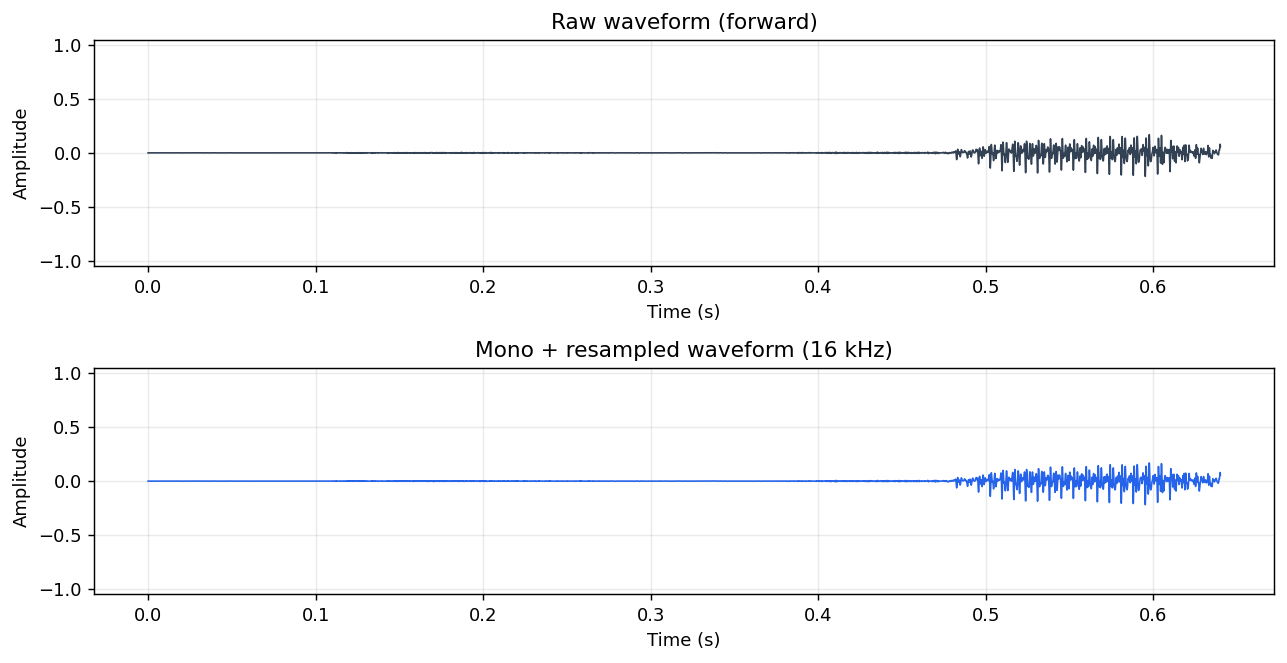

outputs\figures\report_data_preparation\01_audio_loading_standardization.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/01_audio_loading_standardization.png')

In [3]:
mono_waveform = to_mono(raw_waveform)
if raw_sample_rate != sample_rate:
    standardized_waveform = torchaudio.functional.resample(mono_waveform, raw_sample_rate, sample_rate)
else:
    standardized_waveform = mono_waveform

fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=False)
plot_waveform(axes[0], raw_waveform, raw_sample_rate, f"Raw waveform ({example_label})", "#334155")
plot_waveform(axes[1], standardized_waveform, sample_rate, "Mono + resampled waveform (16 kHz)", "#2563eb")
fig.tight_layout()
save_figure(fig, "01_audio_loading_standardization.png")

## 2. Segmentation and Fixed-Length Windowing

Segmentation: chuẩn hóa từng command clip thành một cửa sổ cố định 1 giây. Clip dài hơn 1 giây được crop; clip ngắn hơn được zero-pad. Với audio lệch thời điểm, speech alignment có thể center vùng speech active vào cửa sổ 1 giây.

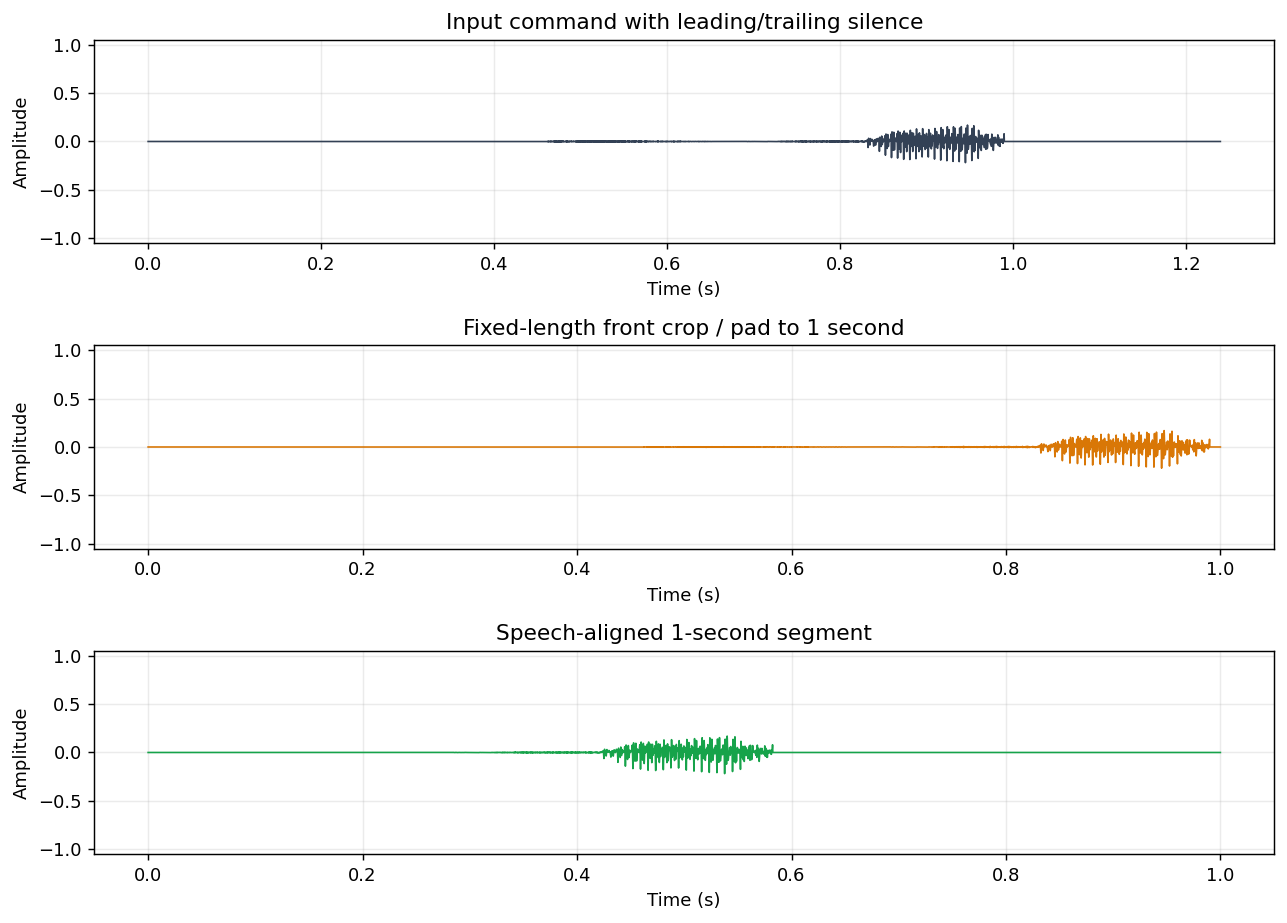

outputs\figures\report_data_preparation\02_segmentation_fixed_length.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/02_segmentation_fixed_length.png')

In [4]:
offset_waveform = torch.cat(
    [torch.zeros(1, int(0.35 * sample_rate)), standardized_waveform, torch.zeros(1, int(0.25 * sample_rate))],
    dim=-1,
)
front_crop = fix_length(offset_waveform, target_num_samples)
aligned_crop = align_active_speech(offset_waveform, sample_rate=sample_rate, target_num_samples=target_num_samples)

fig, axes = plt.subplots(3, 1, figsize=(10, 7.2), sharex=False)
plot_waveform(axes[0], offset_waveform, sample_rate, "Input command with leading/trailing silence", "#334155")
plot_waveform(axes[1], front_crop, sample_rate, "Fixed-length front crop / pad to 1 second", "#d97706")
plot_waveform(axes[2], aligned_crop, sample_rate, "Speech-aligned 1-second segment", "#16a34a")
fig.tight_layout()
save_figure(fig, "02_segmentation_fixed_length.png")

## 3. Noise Handling / Noise Reduction

Bước noise handling giúp giảm ảnh hưởng của background noise trong môi trường thật. Notebook minh họa bằng cách thêm nhiễu nền rồi áp dụng spectral subtraction cơ bản cho stationary noise.

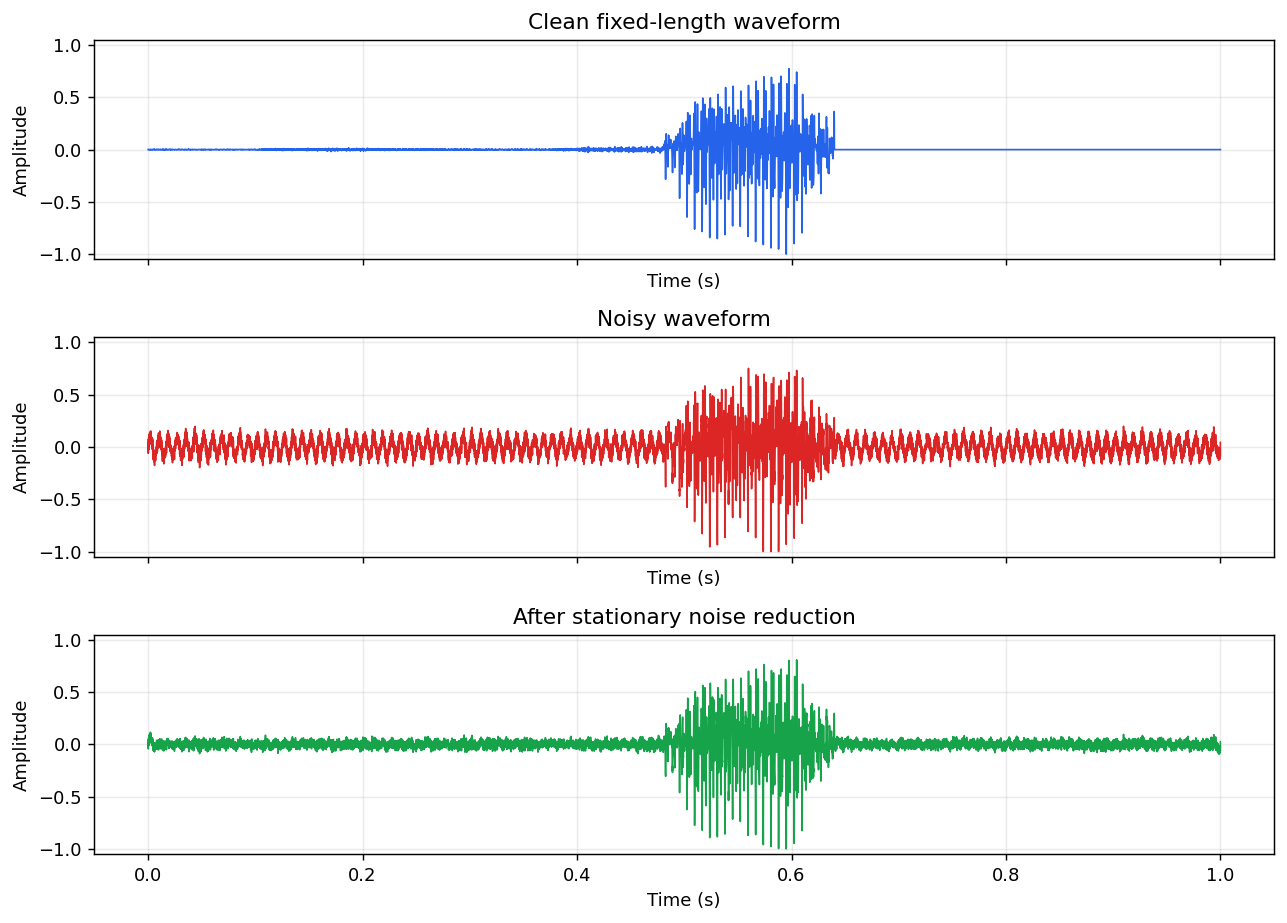

outputs\figures\report_data_preparation\03_noise_handling_waveform.png


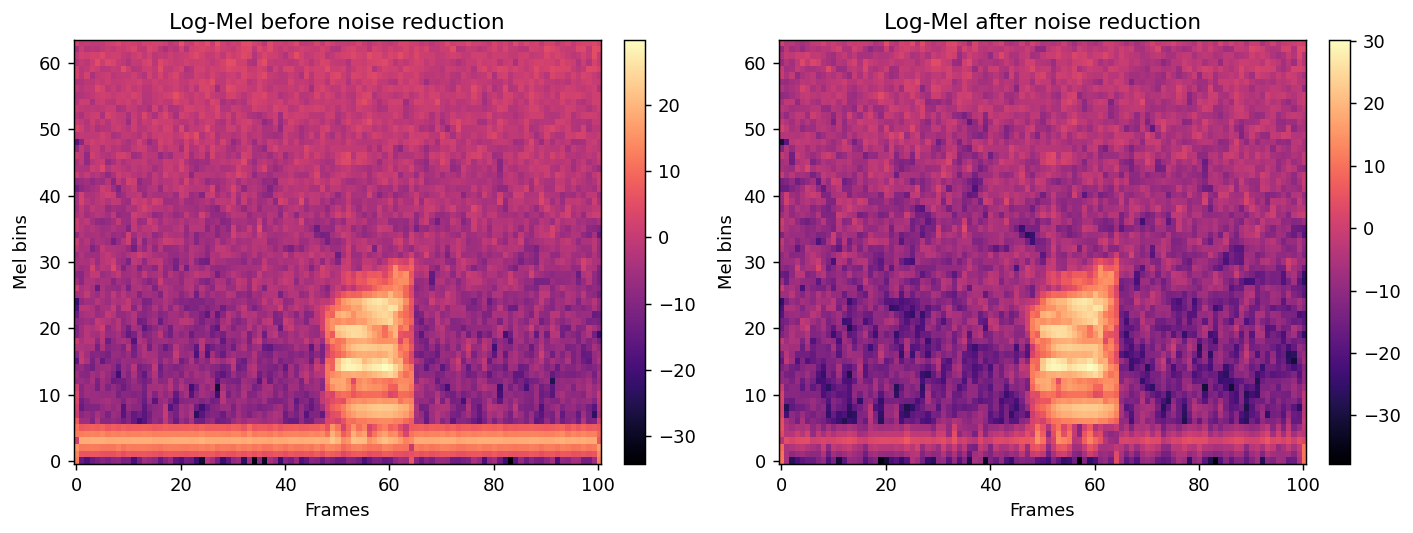

outputs\figures\report_data_preparation\04_noise_handling_logmel.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/04_noise_handling_logmel.png')

In [5]:
clean_fixed = preprocess_waveform(
    standardized_waveform,
    sample_rate=sample_rate,
    target_sample_rate=sample_rate,
    target_num_samples=target_num_samples,
    normalize=True,
)
t = time_axis(clean_fixed.squeeze(), sample_rate).unsqueeze(0)
stationary_noise = 0.09 * torch.sin(2 * math.pi * 120 * t) + 0.035 * torch.randn_like(clean_fixed)
noisy_waveform = (clean_fixed + stationary_noise).clamp(-1.0, 1.0)
denoised_waveform = reduce_stationary_noise(noisy_waveform, reduction_strength=0.9)
denoised_waveform = normalize_amplitude(denoised_waveform)

fig, axes = plt.subplots(3, 1, figsize=(10, 7.2), sharex=True)
plot_waveform(axes[0], clean_fixed, sample_rate, "Clean fixed-length waveform", "#2563eb")
plot_waveform(axes[1], noisy_waveform, sample_rate, "Noisy waveform", "#dc2626")
plot_waveform(axes[2], denoised_waveform, sample_rate, "After stationary noise reduction", "#16a34a")
fig.tight_layout()
save_figure(fig, "03_noise_handling_waveform.png")

logmel = LogMelExtractor(sample_rate=sample_rate)
with torch.no_grad():
    noisy_logmel = logmel(noisy_waveform)
    denoised_logmel = logmel(denoised_waveform)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_feature(axes[0], noisy_logmel, "Log-Mel before noise reduction", "Mel bins")
plot_feature(axes[1], denoised_logmel, "Log-Mel after noise reduction", "Mel bins")
fig.tight_layout()
save_figure(fig, "04_noise_handling_logmel.png")

## 4. Amplitude Normalization

Normalization giảm khác biệt do người nói to/nhỏ hoặc khoảng cách microphone khác nhau. Pipeline scale waveform theo peak amplitude để đưa biên độ về khoảng ổn định.

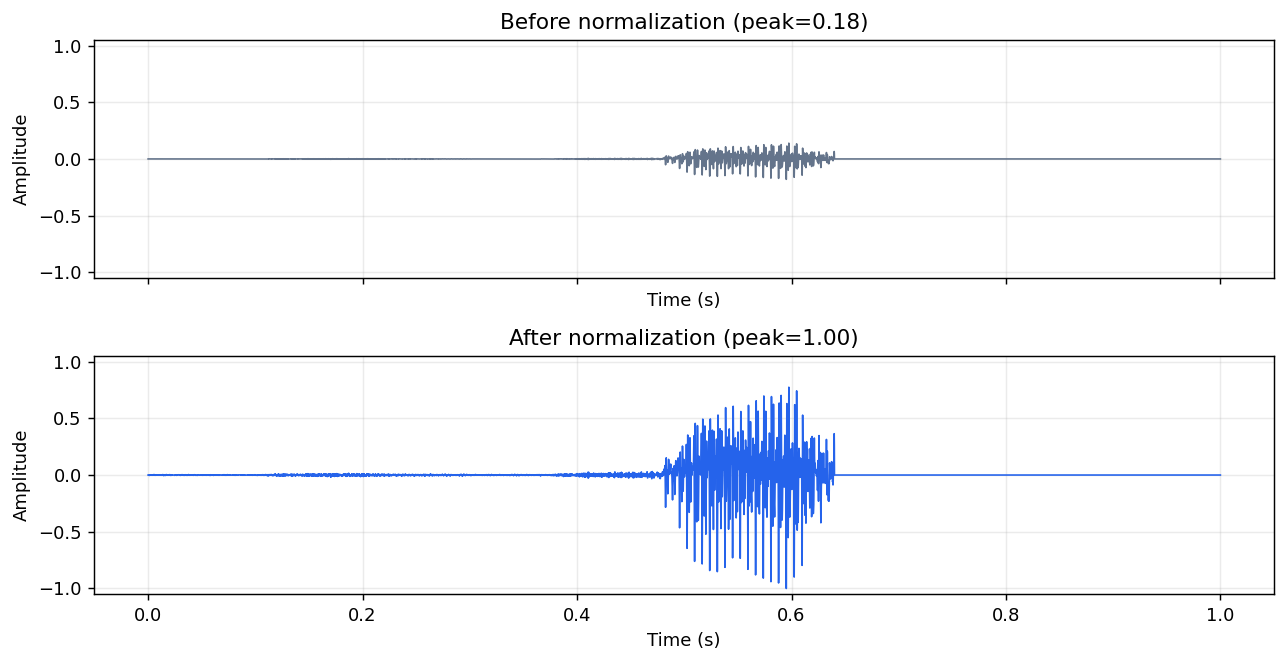

outputs\figures\report_data_preparation\05_amplitude_normalization.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/05_amplitude_normalization.png')

In [6]:
quiet_waveform = 0.18 * clean_fixed
normalized_waveform = normalize_amplitude(quiet_waveform)
before_peak = quiet_waveform.abs().max().item()
after_peak = normalized_waveform.abs().max().item()

fig, axes = plt.subplots(2, 1, figsize=(10, 5.2), sharex=True)
plot_waveform(axes[0], quiet_waveform, sample_rate, f"Before normalization (peak={before_peak:.2f})", "#64748b")
plot_waveform(axes[1], normalized_waveform, sample_rate, f"After normalization (peak={after_peak:.2f})", "#2563eb")
fig.tight_layout()
save_figure(fig, "05_amplitude_normalization.png")

## 5. Label Mapping and Unknown Class Construction

Các lệnh điều hướng giữ nguyên nhãn: `forward`, `backward`, `left`, `right`, `stop`. Những word khác trong Speech Commands được gom thành `unknown` để hệ thống có thể ignore lệnh ngoài tập điều hướng.

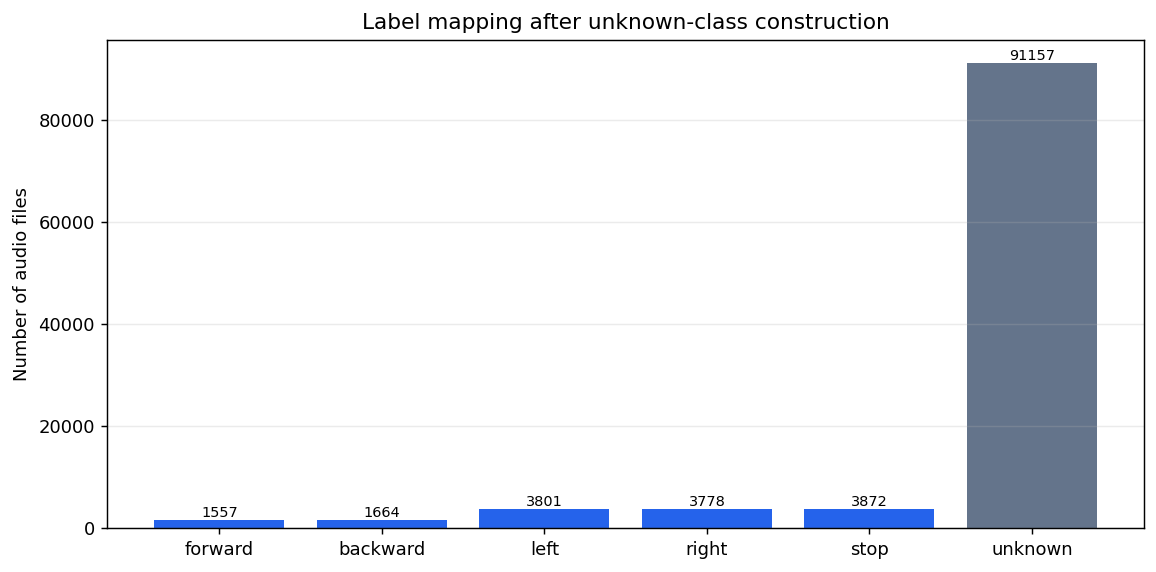

outputs\figures\report_data_preparation\06_label_mapping_unknown_class.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/06_label_mapping_unknown_class.png')

In [7]:
dataset_root = PROJECT_ROOT / "data/raw/SpeechCommands/speech_commands_v0.02"

def count_label_files(root: Path) -> Counter:
    counts = Counter()
    if not root.exists():
        return counts
    for label_dir in root.iterdir():
        if label_dir.is_dir() and not label_dir.name.startswith("_"):
            try:
                counts[label_dir.name] = len(list(label_dir.glob("*.wav")))
            except PermissionError:
                counts[label_dir.name] = 0
    return counts

label_counts = count_label_files(dataset_root)
if label_counts:
    mapped_counts = Counter({label: label_counts[label] for label in commands})
    mapped_counts[unknown_label] = sum(count for label, count in label_counts.items() if label not in commands)
else:
    mapped_counts = Counter({"forward": 120, "backward": 115, "left": 130, "right": 128, "stop": 125, "unknown": 150})

labels = commands + [unknown_label]
values = [mapped_counts[label] for label in labels]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(labels, values, color=["#2563eb"] * len(commands) + ["#64748b"])
ax.set_title("Label mapping after unknown-class construction")
ax.set_ylabel("Number of audio files")
ax.grid(axis="y", alpha=0.25)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(bar.get_height())), ha="center", va="bottom", fontsize=8)
fig.tight_layout()
save_figure(fig, "06_label_mapping_unknown_class.png")

## 6. Dataset Splitting

Project dùng official split của Google Speech Commands. Training dùng để học model, validation dùng để chọn checkpoint/tune threshold, còn testing chỉ dùng để đánh giá & báo cáo kết quả cuối.

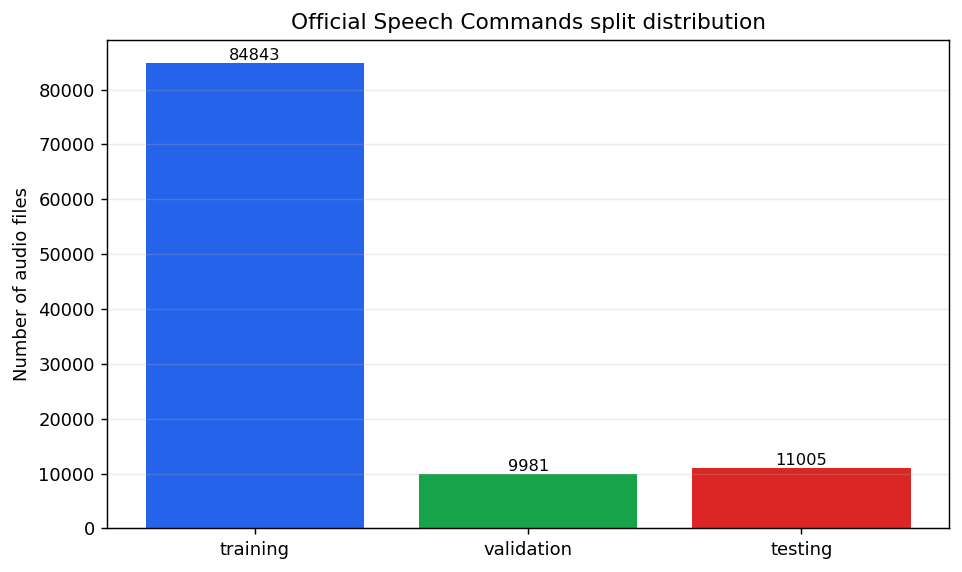

outputs\figures\report_data_preparation\07_dataset_split_distribution.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/07_dataset_split_distribution.png')

In [8]:
def load_split_lists(root: Path) -> tuple[set[str], set[str]]:
    validation = set()
    testing = set()
    validation_file = root / "validation_list.txt"
    testing_file = root / "testing_list.txt"
    if validation_file.exists():
        validation = {line.strip().replace("\\", "/") for line in validation_file.read_text().splitlines() if line.strip()}
    if testing_file.exists():
        testing = {line.strip().replace("\\", "/") for line in testing_file.read_text().splitlines() if line.strip()}
    return validation, testing

def count_splits(root: Path) -> Counter:
    if not root.exists():
        return Counter({"training": 500, "validation": 100, "testing": 100})
    validation, testing = load_split_lists(root)
    split_counts = Counter()
    for label_dir in root.iterdir():
        if not label_dir.is_dir() or label_dir.name.startswith("_"):
            continue
        try:
            wav_files = list(label_dir.glob("*.wav"))
        except PermissionError:
            continue
        for wav_path in wav_files:
            rel = f"{label_dir.name}/{wav_path.name}"
            if rel in validation:
                split_counts["validation"] += 1
            elif rel in testing:
                split_counts["testing"] += 1
            else:
                split_counts["training"] += 1
    return split_counts

split_counts = count_splits(dataset_root)
split_labels = ["training", "validation", "testing"]
split_values = [split_counts[label] for label in split_labels]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(split_labels, split_values, color=["#2563eb", "#16a34a", "#dc2626"])
ax.set_title("Official Speech Commands split distribution")
ax.set_ylabel("Number of audio files")
ax.grid(axis="y", alpha=0.25)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
fig.tight_layout()
save_figure(fig, "07_dataset_split_distribution.png")

## 7. Training Augmentation Examples

Augmentation chỉ áp dụng cho training split. Mục tiêu là tăng robustness với recording thật: background noise, command lệch thời điểm, và volume khác nhau.

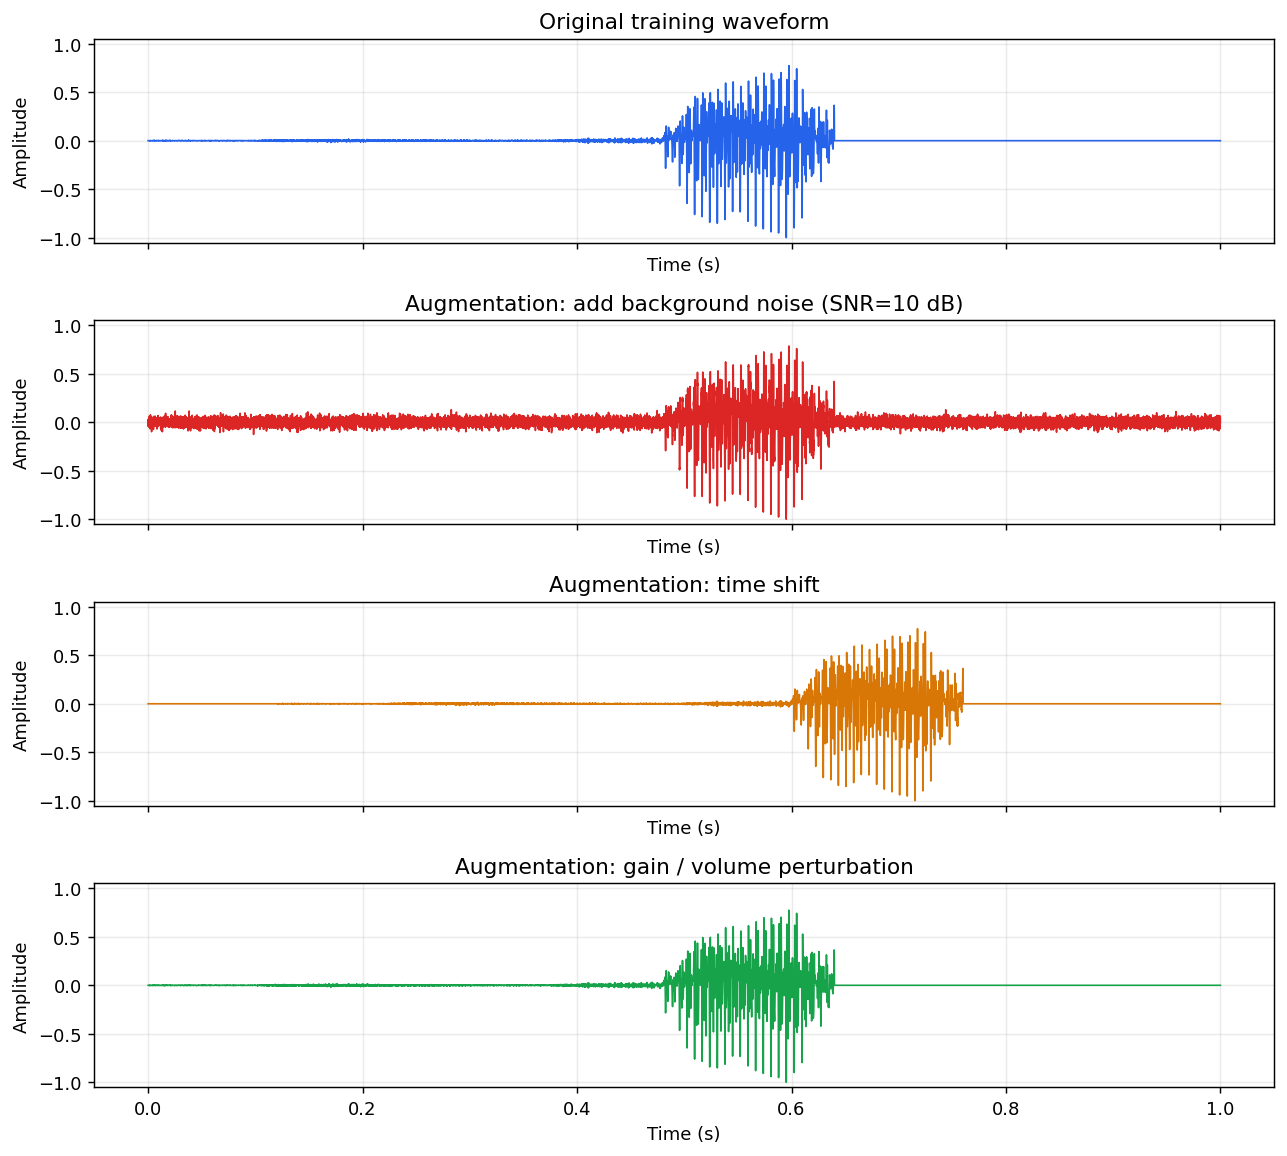

outputs\figures\report_data_preparation\08_training_augmentation_waveforms.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/08_training_augmentation_waveforms.png')

In [9]:
noise_augmented = add_noise_at_snr(clean_fixed, snr_db=10.0, generator=torch.Generator().manual_seed(7)).clamp(-1.0, 1.0)
shift_augmented = shift_waveform(clean_fixed, shift_samples=int(0.12 * sample_rate))
gain_augmented = normalize_amplitude(apply_gain_db(clean_fixed, gain_db=-8.0))

fig, axes = plt.subplots(4, 1, figsize=(10, 9.0), sharex=True)
plot_waveform(axes[0], clean_fixed, sample_rate, "Original training waveform", "#2563eb")
plot_waveform(axes[1], noise_augmented, sample_rate, "Augmentation: add background noise (SNR=10 dB)", "#dc2626")
plot_waveform(axes[2], shift_augmented, sample_rate, "Augmentation: time shift", "#d97706")
plot_waveform(axes[3], gain_augmented, sample_rate, "Augmentation: gain / volume perturbation", "#16a34a")
fig.tight_layout()
save_figure(fig, "08_training_augmentation_waveforms.png")

## 8. Final Model Input Representation

Sau preprocessing, waveform được chuyển thành feature representation cho model. Pipeline chính dùng Log-Mel spectrogram; notebook cũng minh họa MFCC để phục vụ phần so sánh approach.

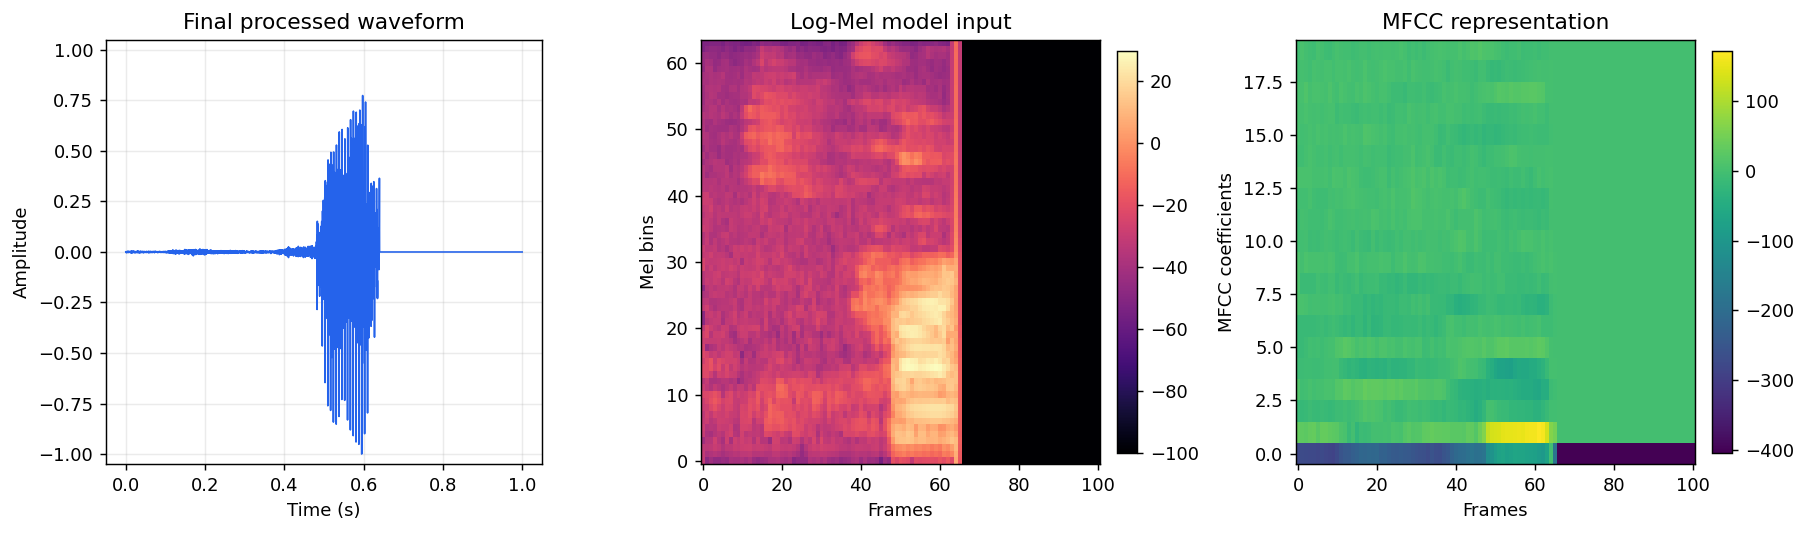

outputs\figures\report_data_preparation\09_final_model_input_features.png


WindowsPath('d:/3rd_Year/HK2/Dot2/SPPR/final_project/SPPR-Speech-Command-Recognition-for-Robot-Navigation/outputs/figures/report_data_preparation/09_final_model_input_features.png')

In [10]:
with torch.no_grad():
    final_logmel = LogMelExtractor(sample_rate=sample_rate)(clean_fixed)
    mfcc_transform = torchaudio.transforms.MFCC(
        sample_rate=sample_rate,
        n_mfcc=20,
        melkwargs={"n_fft": 400, "win_length": 400, "hop_length": 160, "n_mels": 64},
    )
    final_mfcc = mfcc_transform(clean_fixed)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
plot_waveform(axes[0], clean_fixed, sample_rate, "Final processed waveform", "#2563eb")
plot_feature(axes[1], final_logmel, "Log-Mel model input", "Mel bins")
plot_feature(axes[2], final_mfcc, "MFCC representation", "MFCC coefficients", cmap="viridis")
fig.tight_layout()
save_figure(fig, "09_final_model_input_features.png")

## 9. Exported Figures for Report

Các file figure nên chọn lọc đưa vào mục 2.3:

- `01_audio_loading_standardization.png`
- `02_segmentation_fixed_length.png`
- `03_noise_handling_waveform.png`
- `04_noise_handling_logmel.png`
- `05_amplitude_normalization.png`
- `06_label_mapping_unknown_class.png`
- `07_dataset_split_distribution.png`
- `08_training_augmentation_waveforms.png`
- `09_final_model_input_features.png`